## Calculate the maximum substructure that a set of molecules has in common.

**Contents in Theory**
- Introduction to identification of maximum common substructure in a set of molecules
- Detailed explanation of the FMCS algorithm

**Contents in Practical**
- Load and draw molecules
- Run the FMCS algorithm with different input parameters
- A more diverse set: the EGFR compounds downloaded from ChEMBL
- Identification of MCS using interactive cut-off adaption


### FMCS Algorithm
best_substructure = None
pick one structure in the set as query, all other as targets
for each substructure in the query:
    convert into a SMARTS string based on the desired match properties
    if SMARTS pattern exists in all of the targets:
        then it is a common substructure
        keep track of the maximum of such substructure

**Optimize**
A) Bond elimination
Remove bonds that cannot be part of the MCS
Atom and bond type information has to be present in every input structure
Bond type: string consisting of SMARTS of the first atom, the bond and the second atom
Exclude all bond types not present in all input structures, delete respective edges
Result: fragmented structures with all atom information, but fewer edges (bonds)

B) Use the structure with the smallest largest fragment as the query¶
Heuristic approach:
Find largest fragment of each input structure
Sort input structures ascending by number of bonds in largest fragment
Solve ties with number of atoms or input order as alternative
The structure with the smallest largest fragment becomes the query structure
The ones from the other input structures are the targets

C) Use a breadth-first search (BFS) and a priority queue to enumerate the fragment subgraphs¶
C1
Enumeration based on growing a so called seed
Seed: atoms/bonds in current subgraph, exclusion set (bonds not applicable for growth)
To prevent redundancy:
Initial seed is first bond in the fragment, can potentially grow to size of whole fragment
Second seed is second bond, is excluded from using the first bond
Third seed starts from the third bond, excluded from using the first and second

…

C2
Seed grows along connected bonds (not in exclusions set or already in seed)
All growing possibilities are considered at every step
E.g. if there are N possible bonds for extension, 2𝑁−1 possible new seeds are added to queue
Enumeration ends when there are no new bonds to add to subgraph (exclude seed from queue)
Largest seed will be processed first

D) Prune seeds not present in all of the other structures¶
At each growth state → check if new seed exists in all other structures
Else: Exclude seed from queue

E) Prune seeds without sufficient growing potential¶
Evaluation of growth potential from exclusion list and possible edges for extension
If potential smaller than current best subgraph → exclude seed from queue

In [1]:
from collections import defaultdict
from pathlib import Path
from copy import deepcopy
import random
import numpy as np
from ipywidgets import interact, fixed, widgets
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, Geometry
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdFMCS
from rdkit.Chem import PandasTools

random.seed(0)
np.random.seed(0)

In [2]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

Set with 145 molecules loaded.
First 10 molecules:


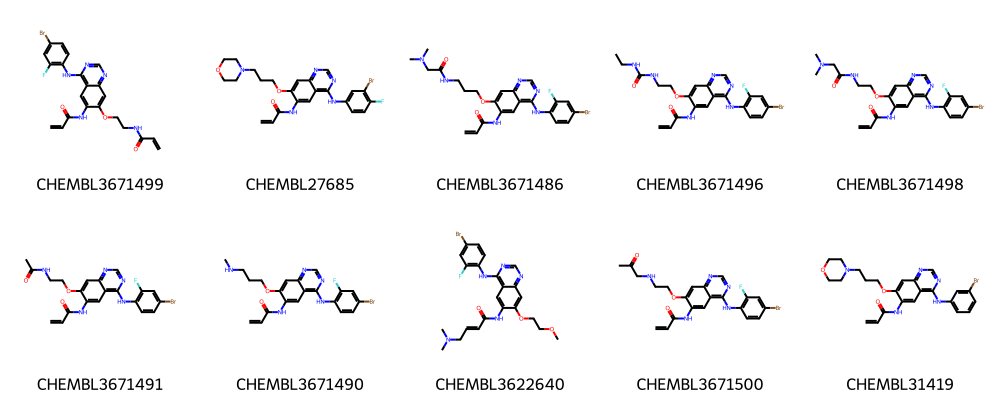

In [4]:
sdf = Path(DATA_DIR / "molecule_set_largest_cluster.sdf")
supplier = Chem.ForwardSDMolSupplier(sdf)
mols = list(supplier)

print(f"Set with {len(mols)} molecules loaded.\nFirst 10 molecules:")
# Display first 10 molecules
num_mols = 10
legends = [mol.GetProp("_Name") for mol in mols]
Draw.MolsToGridImage(mols[:num_mols], legends=legends[:num_mols], molsPerRow=5)

## FMCS Algorith - Running with different input parameters:

In [5]:
# Case 1: Input = list of molecules
maxcs1 = rdFMCS.FindMCS(mols)
print(f"MCS1 contains {maxcs1.numAtoms} atoms and {maxcs1.numBonds} bonds.")
print("MCS SMARTS string:", maxcs1.smartsString)

MCS1 contains 24 atoms and 26 bonds.
MCS SMARTS string: [#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]-[#6]-[#6]


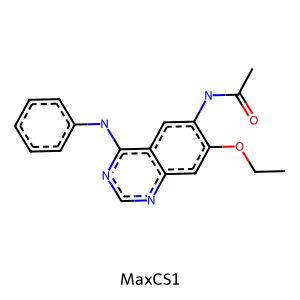

In [7]:
# Draw substructure from Smarts
m1 = Chem.MolFromSmarts(maxcs1.smartsString)
Draw.MolToImage(m1, legend="MaxCS1")

In [10]:
# Helper: Draw molecules with highlighted MCS
def highlight_molecules(molecules: list, mcs: rdFMCS.MCSResult, number: int, label: bool=True, same_orientation: bool=True, **kwargs):
    """Highlight the MCS in our query molecules
    
    Args:
        molecules (list): List of RDKit molecule objects
        mcs (rdFMCS.MCSResult): MCS result object from rdFMCS
        number (int): Number of molecules to display
        label (bool, optional): Whether to label the molecules with their names. Defaults to True.
        same_orientation (bool, optional): Whether to align the molecules in the same orientation. Defaults to True.
        **kwargs: Additional keyword arguments for Draw.MolsToGridImage
    Returns:
        PIL.Image: Image of the molecules with highlighted MCS
    """
    molecules = deepcopy(molecules)
    # convert MCS to molecule
    pattern = Chem.MolFromSmarts(mcs.smartsString)
    # find the matching atoms in each molecule
    matching = [molecule.GetSubstructMatch(pattern) for molecule in molecules[:number]]

    legends = None
    if label:
        legends = [molname.GetProp("_Name") for molname in molecules]

    # Align by matched substructure so they are depicted in the same orientation
    # Adapted from: https://gist.github.com/greglandrum/82d9a86acb3b00d3bb1df502779a5810
    if same_orientation:
        mol, match = molecules[0], matching[0]
        AllChem.Compute2DCoords(mol)
        coords = [mol.GetConformer().GetAtomPosition(x) for x in match]
        coords2D = [Geometry.Point2D(pt.x, pt.y) for pt in coords]
        for mol, match in zip(molecules[1:number], matching[1:number]):
            if not match:
                continue
            coord_dict = {match[i]: coord for i, coord in enumerate(coords2D)}
            AllChem.Compute2DCoords(mol, coordMap=coord_dict)

    return Draw.MolsToGridImage(
        molecules[:number],
        legends=legends,
        molsPerRow=5,
        highlightAtomLists=matching[:number],
        subImgSize=(300, 300),
        **kwargs,
    )

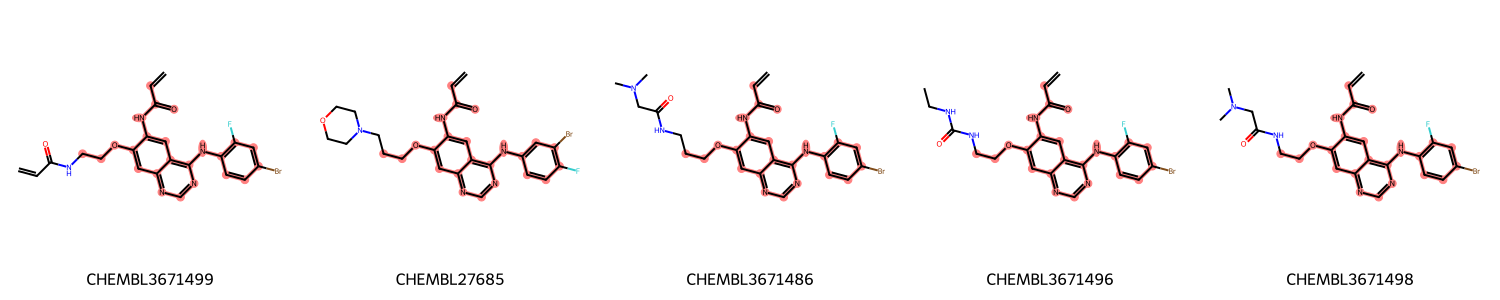

In [11]:
# Highlight the MCS in the first 5 molecules
highlight_molecules(mols, maxcs1, 5)

In [12]:
# Save the highlighted molecules as an SVG file
img = highlight_molecules(mols, maxcs1, 3, useSVG=True)
# Get SVG data
molsvg = img.data
# Set background to transparent & Enlarge size of label
molsvg = molsvg.replace("opacity:1.0", "opacity:0.0").replace("12px", "20px")

# Save altered SVG data to file
with open(DATA_DIR / "mcs_largest_cluster.svg", "w") as f:
    f.write(molsvg)

### Set a Threshold: Lower the threshold for the substructure such that the MCS only has to occur in 80% of the input structures:

In [13]:
maxcs2 = rdFMCS.FindMCS(mols, threshold=0.8)
print(f"MCS2 contains {maxcs2.numAtoms} atoms and {maxcs2.numBonds} bonds.")
print("SMARTS string:", maxcs2.smartsString)

MCS2 contains 28 atoms and 30 bonds.
SMARTS string: [#6]=[#6]-[#6](=[#8])-[#7]-[#6]1:[#6]:[#6]2:[#6](-[#7]-[#6]3:[#6]:[#6]:[#6]:[#6]:[#6]:3-[#9]):[#7]:[#6]:[#7]:[#6]:2:[#6]:[#6]:1-[#8]-[#6]-[#6]-[#7]-[#6]


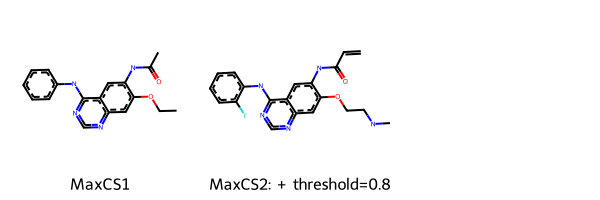

In [14]:
# Draw substructure
m2 = Chem.MolFromSmarts(maxcs2.smartsString)
Draw.MolsToGridImage([m1, m2], legends=["MaxCS1", "MaxCS2: + threshold=0.8"])

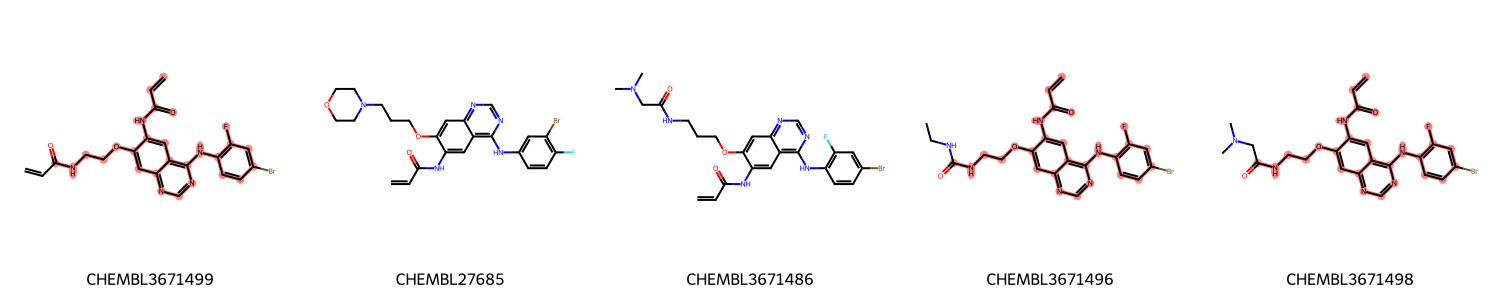

In [15]:
highlight_molecules(mols, maxcs2, 5)

> NOTE: As we can see in this example, some molecules were now left out due to the set threshold (0.8). 
> This threshold allows to find a larger common substructure that contains, e.g., a benzene with a meta-substitution fluor pattern and a longer alkane chain.

### Match Ring Bonds
In the above example it may not be obvious, but by default ring bonds can match non-ring bonds. Often from an application point of view, we want to retain rings. Thus, one can set the ringMatchesRingOnly parameter to True, then only ring bonds match with other ring bonds.

MaxCS3 contains 28 atoms and 30 bonds.
SMARTS string: [#6&!R]=&!@[#6&!R]-&!@[#6&!R](=&!@[#8&!R])-&!@[#7&!R]-&!@[#6]1:&@[#6]:&@[#6]2:&@[#6](-&!@[#7&!R]-&!@[#6]3:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@3-&!@[#9&!R]):&@[#7]:&@[#6]:&@[#7]:&@[#6]:&@2:&@[#6]:&@[#6]:&@1-&!@[#8&!R]-&!@[#6&!R]-&!@[#6&!R]-&!@[#7&!R]-&!@[#6&!R]


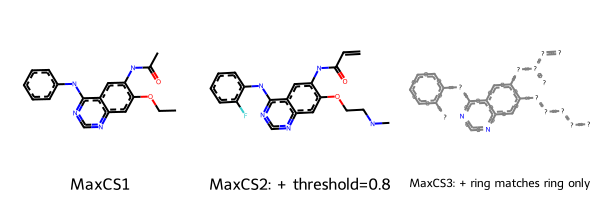

In [16]:
maxcs3 = rdFMCS.FindMCS(mols, threshold=0.8, ringMatchesRingOnly=True)
print(f"MaxCS3 contains {maxcs3.numAtoms} atoms and {maxcs3.numBonds} bonds.")
print("SMARTS string:", maxcs3.smartsString)
# Draw substructure
m3 = Chem.MolFromSmarts(maxcs3.smartsString)
Draw.MolsToGridImage([m1, m2, m3], legends=["MaxCS1", "MaxCS2: + threshold=0.8", "MaxCS3: + ring matches ring only"])

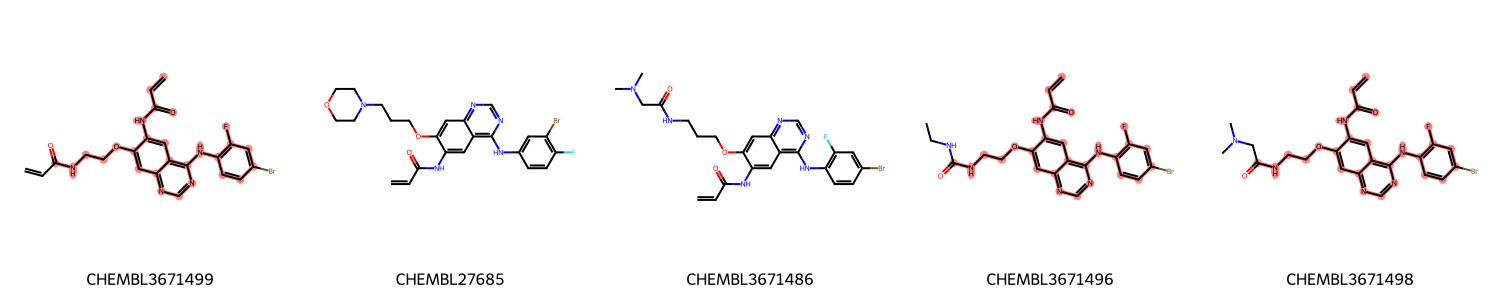

In [17]:
highlight_molecules(mols, maxcs3, 5)

In [18]:
# Read full EGFR data
mol_df = pd.read_csv(DATA_DIR / "EGFR_molecules_ro5_fulfilled.csv", index_col=0)
mol_df.reset_index(drop=True, inplace=True)
print("Total number of compounds:", mol_df.shape[0])

# Only keep molecules with pIC50 > 9 (IC50 > 1nM)
mol_df = mol_df[mol_df.pIC50 > 9]
print("Number of compounds with pIC50 > 9:", mol_df.shape[0])

Total number of compounds: 4661
Number of compounds with pIC50 > 9: 164


In [19]:
# Add molecule column to data frame
PandasTools.AddMoleculeColumnToFrame(mol_df, "smiles")
mol_df.head(2)

,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled,ROMol
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True,<rdkit.Chem.rdchem.Mol object at 0x116de7ae0>
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,388.265,4.9333,1,5,56.27,6,11.221849,True,<rdkit.Chem.rdchem.Mol object at 0x116de7d10>


In [20]:
# Run MCS calculations on the highly active compounds (pIC50 > 9):
mols_diverse = []
# Note: discarded variables we do not care about are usually referred to with a single underscore
for _, row in mol_df.iterrows():
    m = Chem.MolFromSmiles(row.smiles)
    m.SetProp("_Name", row.molecule_chembl_id)
    mols_diverse.append(m)

# Run calculations on a random sample of 50 molecules:
mols_diverse_sample = random.sample(mols_diverse, 50)

In [21]:
# Lower threshold ato account for diversity in the larger dataset:
threshold_diverse = 0.7
mcs1 = rdFMCS.FindMCS(mols_diverse_sample)
print("SMARTS string1:", mcs1.smartsString)
mcs2 = rdFMCS.FindMCS(mols_diverse_sample, threshold=threshold_diverse)
print("SMARTS string2:", mcs2.smartsString)
mcs3 = rdFMCS.FindMCS(mols_diverse_sample, ringMatchesRingOnly=True, threshold=threshold_diverse)
print("SMARTS string3:", mcs3.smartsString)

SMARTS string1: [#6](:[#6]:,-[#6]:,-[#6]):[#6]:[#6]:,-[#7]:,-[#6]:,-[#7]:,-[#6]
SMARTS string2: [#6](:[#6]:,-[#6]:[#6]):[#6]:[#6]:,-[#7]:,-[#6]:[#7]:[#6]-,:[#7]-,:[#6](:,-[#6]:[#6]:[#6]:,-[#6]):,-[#6]
SMARTS string3: [#6&R](:&@[#6&R]):&@[#6&R]:&@[#6&R](:&@[#7&R]:&@[#6&R]:&@[#7&R]:&@[#6&R]-&!@[#7&!R]-&!@[#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1):&@[#6&R]


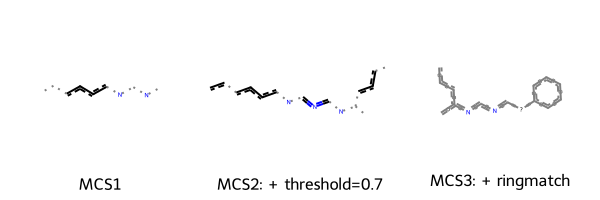

In [23]:
# Draw substructures
m1 = Chem.MolFromSmarts(mcs1.smartsString)
m2 = Chem.MolFromSmarts(mcs2.smartsString)
m3 = Chem.MolFromSmarts(mcs3.smartsString)

Draw.MolsToGridImage(
    [m1, m2, m3],
    legends=[
        "MCS1",
        f"MCS2: + threshold={threshold_diverse}",
        "MCS3: + ringmatch",
    ],
)

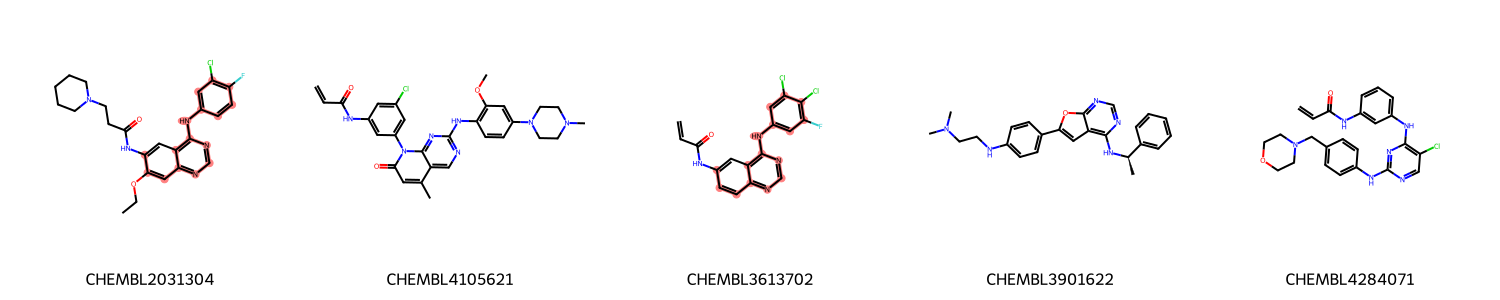

In [24]:
highlight_molecules(mols_diverse_sample, mcs3, 5)

### Identification of MCS using interactive cut-off adaption¶
Change the threshold interactively using a helper function:

In [25]:
def render_mcs(molecules, percentage):
    """Interactive widget helper. `molecules` must be wrapped in `ipywidgets.fixed()`,
    while `percentage` will be determined by an IntSlider widget."""
    tmcs = rdFMCS.FindMCS(molecules, threshold=percentage / 100.0)
    if tmcs is None:
        print("No MCS found")
        return None

    m = Chem.MolFromSmarts(tmcs.smartsString)
    print(tmcs.smartsString)
    return m

In [26]:
# Note that the slider may take a few seconds to react
interact(
    render_mcs,
    molecules=fixed(mols_diverse_sample),
    percentage=widgets.IntSlider(min=0, max=100, step=10, value=70),
)

interactive(children=(IntSlider(value=70, description='percentage', step=10), Output()), _dom_classes=('widget…

<function __main__.render_mcs(molecules, percentage)>

> NOTE:

Why is the calculation of the maximum common substructure (MCS) useful?
It identifies the largest shared structural fragment between two or more chemical compounds. This core graph-matching technique helps measure local similarities, cluster large molecular databases, align 2D/3D chemical drawings, and predict biological activity patterns.
**Key **Uses in Cheminformatics**
- Flexible Similarity Searching: Unlike rigid whole-molecule fingerprints, MCS pinpoints exact local core overlaps even when outer molecular chains differ.
- Hierarchical Clustering: It groups large sets of diverse chemical compounds based on actual core atomic alignment.
- Automated Reaction Mapping: It tracks how specific molecular bonds transform and move during chemical reactions.
- Scaffold Identification: It detects core structural templates crucial for drug design and scaffold hopping.
- Visual Alignment: It allows software to neatly superimpose and highlight common parts across multiple molecule diagrams.

How can MCS can be calculated?
The Maximum Common Substructure (MCS) is calculated by treating molecules as mathematical graphs where atoms are nodes and bonds are edges. Because finding the exact MCS is an NP-hard problem (computationally demanding), calculations rely on specific graph algorithms and optimization strategies.

What does the typical fragment of an active EGFR compound look like?
A typical fragment or core scaffold of an active Epidermal Growth Factor Receptor (EGFR) inhibitor consists of an electron-deficient, nitrogen-containing bicyclic heterocycle designed to mimic the adenine ring of ATP.
The structural blueprint of these fragments is defined by distinct generational scaffolds and specific functional vectors:
1. The Core Scaffolds
Quinazoline Core (1st & 2nd Generation): A bicyclic structure composed of fused benzene and pyrimidine rings. This is the most classic EGFR fragment seen in FDA-approved drugs like Gefitinib and Erlotinib.
Mono- or Diaminopyrimidine Core (3rd Generation): A single pyrimidine ring variant featuring specialized amino substitutions. This fragment is optimized to overcome resistant mutations (like T790M) and is the structural foundation of Osimertinib.